# 04 · Clustering

This notebook covers the fourth and final phase of the Barcelona Housing Affordability Analysis:

- Feature selection and scaling for clustering
- Optimal number of clusters using the Elbow Method and Silhouette Score
- K-Means clustering of Barcelona neighbourhoods by affordability profile
- Cluster interpretation and visualisation

**Input:** `data/processed/master_dataset.csv`  
**Output:** Clustered dataset and visualisations saved to `visualizations/`

In [3]:
import os
import warnings
os.environ['OMP_NUM_THREADS'] = '1'
warnings.filterwarnings('ignore', message='KMeans is known to have a memory leak')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, clear_output

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
VIZ       = ROOT / "visualizations"

df = pd.read_csv(PROCESSED / "master_dataset.csv")

# Use 2022 snapshot for clustering
df_2022 = (
    df[df['year'] == 2022]
    .groupby(['district_id', 'district_name', 'neighbourhood_id', 'neighbourhood_name'])
    .agg(
        avg_unit_cadastral_value = ('unit_cadastral_value', 'mean'),
        avg_income_per_capita    = ('income_per_capita', 'mean'),
        avg_affordability_ratio  = ('affordability_ratio', 'mean'),
        avg_pct_small_dwellings  = ('pct_small_dwellings', 'mean'),
        total_dwellings          = ('total_dwellings', 'sum')
    )
    .reset_index()
)

print(f"Shape: {df_2022.shape}")
print(df_2022.head())

Shape: (73, 9)
   district_id district_name  neighbourhood_id  \
0            1  Ciutat Vella                 1   
1            1  Ciutat Vella                 2   
2            1  Ciutat Vella                 3   
3            1  Ciutat Vella                 4   
4            2      Eixample                 5   

                      neighbourhood_name  avg_unit_cadastral_value  \
0                               el Raval                    886.68   
1                               el Gòtic                  1,063.43   
2                         la Barceloneta                  1,222.40   
3  Sant Pere, Santa Caterina i la Ribera                  1,032.64   
4                          el Fort Pienc                  1,078.42   

   avg_income_per_capita  avg_affordability_ratio  avg_pct_small_dwellings  \
0              14,221.14                     0.06                    55.57   
1              18,668.11                     0.06                    33.51   
2              17,965.91     

## 1. Feature Selection & Scaling

We cluster neighbourhoods using four features:
- `avg_unit_cadastral_value` — property value proxy
- `avg_income_per_capita` — purchasing power
- `avg_affordability_ratio` — value/income relationship
- `avg_pct_small_dwellings` — housing size pressure

All features are standardised using StandardScaler before clustering.

In [6]:
FEATURES = [
    'avg_unit_cadastral_value',
    'avg_income_per_capita',
    'avg_affordability_ratio',
    'avg_pct_small_dwellings'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_2022[FEATURES])

print("Scaled features shape:", X_scaled.shape)
print("\nMean after scaling (should be ~0):")
print(X_scaled.mean(axis=0).round(4))
print("\nStd after scaling (should be ~1):")
print(X_scaled.std(axis=0).round(4))

Scaled features shape: (73, 4)

Mean after scaling (should be ~0):
[-0. -0.  0. -0.]

Std after scaling (should be ~1):
[1. 1. 1. 1.]


## 2. Optimal Number of Clusters

We use two methods to determine the optimal k:
- **Elbow Method** — inertia (within-cluster sum of squares) vs k
- **Silhouette Score** — measures how well each point fits its cluster vs others

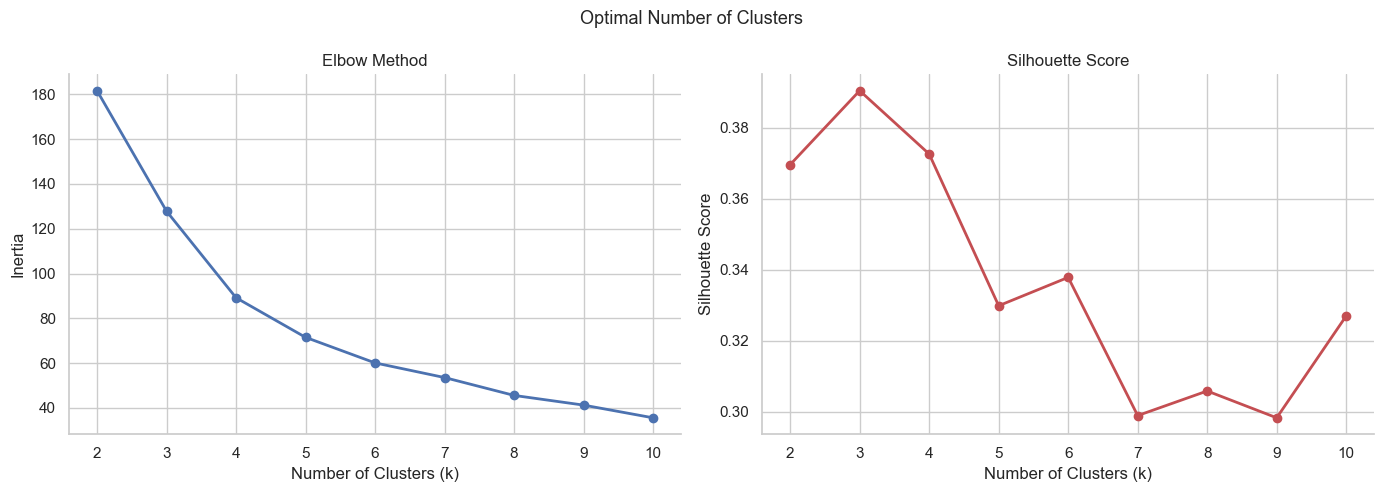


Silhouette scores:
  k=2: 0.3697
  k=3: 0.3905
  k=4: 0.3727
  k=5: 0.3299
  k=6: 0.3379
  k=7: 0.2989
  k=8: 0.3059
  k=9: 0.2983
  k=10: 0.3270


In [8]:
inertias = []
silhouettes = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_RANGE, inertias, marker='o', linewidth=2, color='#4C72B0')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(K_RANGE, silhouettes, marker='o', linewidth=2, color='#C44E52')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Optimal Number of Clusters', fontsize=13)
plt.tight_layout()
plt.savefig(VIZ / '08_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSilhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    print(f"  k={k}: {s:.4f}")

## 3. K-Means Clustering (k=3)

Both the Elbow Method and the Silhouette Score (maximum at k=3: 0.39) point to **3 clusters** as the optimal solution. This also aligns with a natural interpretation of affordability profiles:

- **Cluster A** — Affordable
- **Cluster B** — Pressured  
- **Cluster C** — Critical

In [10]:
K_OPTIMAL = 3

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_2022['cluster'] = km_final.fit_predict(X_scaled)

# Summarise clusters
cluster_summary = (
    df_2022.groupby('cluster')
    .agg(
        neighbourhoods           = ('neighbourhood_name', 'count'),
        avg_unit_cadastral_value = ('avg_unit_cadastral_value', 'mean'),
        avg_income_per_capita    = ('avg_income_per_capita', 'mean'),
        avg_affordability_ratio  = ('avg_affordability_ratio', 'mean'),
        avg_pct_small_dwellings  = ('avg_pct_small_dwellings', 'mean')
    )
    .round(2)
)

print("=== CLUSTER SUMMARY ===")
print(cluster_summary.to_string())

=== CLUSTER SUMMARY ===
         neighbourhoods  avg_unit_cadastral_value  avg_income_per_capita  avg_affordability_ratio  avg_pct_small_dwellings
cluster                                                                                                                   
0                    44                    688.25              18,940.71                     0.04                    34.12
1                     6                    954.75              17,239.72                     0.06                    56.29
2                    23                  1,206.38              28,920.79                     0.04                    21.18


## 4. Cluster Labelling & Interpretation

| Cluster | Label | Neighbourhoods | Profile |
|---|---|---|---|
| 0 | Affordable | 44 | Low cadastral value, medium-low income, low affordability pressure |
| 1 | Critical | 6 | Medium cadastral value, lowest income, highest affordability ratio, high small dwelling share |
| 2 | High-Value | 23 | High cadastral value, high income, low affordability ratio despite high prices |

In [12]:
CLUSTER_LABELS = {0: 'Affordable', 1: 'Critical', 2: 'High-Value'}
df_2022['cluster_label'] = df_2022['cluster'].map(CLUSTER_LABELS)

print("=== CRITICAL CLUSTER NEIGHBOURHOODS ===")
print(df_2022[df_2022['cluster_label'] == 'Critical']
      [['district_name', 'neighbourhood_name', 
        'avg_affordability_ratio', 'avg_income_per_capita', 
        'avg_pct_small_dwellings']]
      .sort_values('avg_affordability_ratio', ascending=False)
      .to_string(index=False))

print("\n=== HIGH-VALUE CLUSTER NEIGHBOURHOODS ===")
print(df_2022[df_2022['cluster_label'] == 'High-Value']
      [['district_name', 'neighbourhood_name',
        'avg_affordability_ratio', 'avg_income_per_capita',
        'avg_pct_small_dwellings']]
      .sort_values('avg_income_per_capita', ascending=False)
      .to_string(index=False))

=== CRITICAL CLUSTER NEIGHBOURHOODS ===
 district_name                    neighbourhood_name  avg_affordability_ratio  avg_income_per_capita  avg_pct_small_dwellings
  Ciutat Vella                        la Barceloneta                     0.07              17,965.91                    76.47
  Ciutat Vella                              el Raval                     0.06              14,221.14                    55.57
  Ciutat Vella                              el Gòtic                     0.06              18,668.11                    33.51
  Ciutat Vella Sant Pere, Santa Caterina i la Ribera                     0.05              19,655.15                    45.51
Sants-Montjuïc                          el Poble Sec                     0.05              18,346.00                    46.43
    Nou Barris                           Can Peguera                     0.04              14,582.00                    80.26

=== HIGH-VALUE CLUSTER NEIGHBOURHOODS ===
      district_name                

## 5. Cluster Visualisations

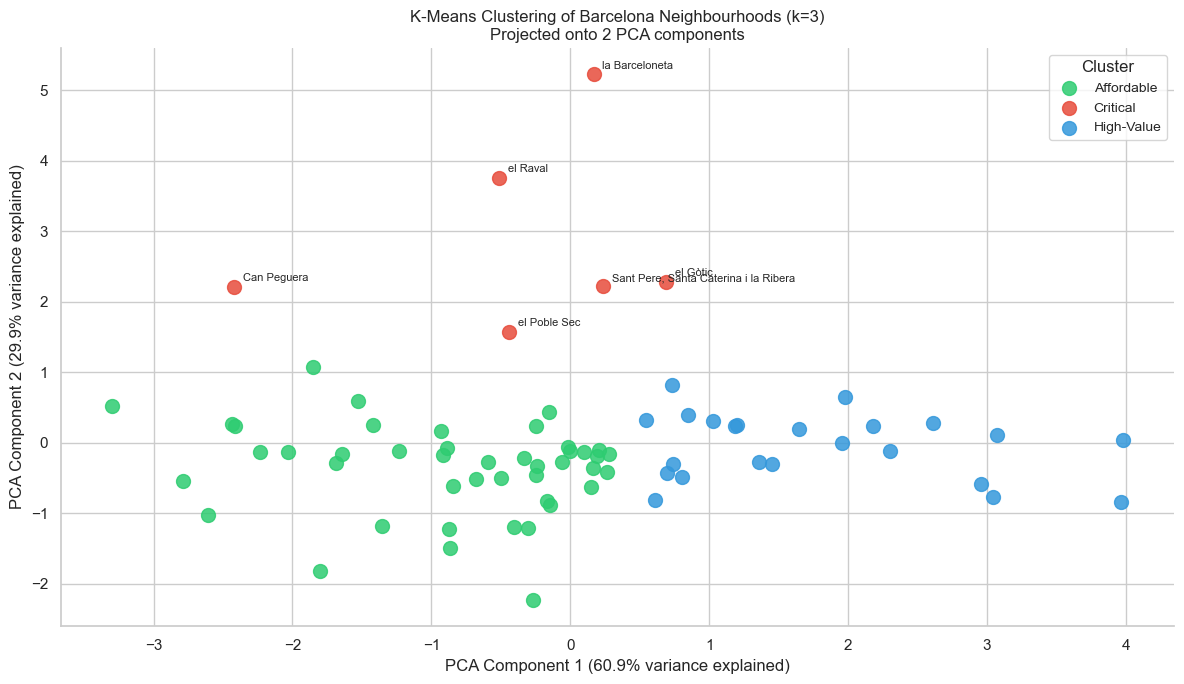

Variance explained by 2 components: 90.8%


In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_2022['pca_1'] = X_pca[:, 0]
df_2022['pca_2'] = X_pca[:, 1]

palette = {'Affordable': '#2ecc71', 'Critical': '#e74c3c', 'High-Value': '#3498db'}

fig, ax = plt.subplots(figsize=(12, 7))
for label, group in df_2022.groupby('cluster_label'):
    ax.scatter(group['pca_1'], group['pca_2'],
               c=palette[label], label=label, s=100, alpha=0.85, zorder=3)

# Annotate extreme cases
for _, row in df_2022[df_2022['cluster_label'] == 'Critical'].iterrows():
    ax.annotate(row['neighbourhood_name'],
                xy=(row['pca_1'], row['pca_2']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)

explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PCA Component 1 ({explained[0]:.1f}% variance explained)')
ax.set_ylabel(f'PCA Component 2 ({explained[1]:.1f}% variance explained)')
ax.set_title('K-Means Clustering of Barcelona Neighbourhoods (k=3)\n'
             'Projected onto 2 PCA components', fontsize=12)
ax.legend(title='Cluster', fontsize=10)

plt.tight_layout()
plt.savefig(VIZ / '09_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Variance explained by 2 components: {sum(explained):.1f}%")

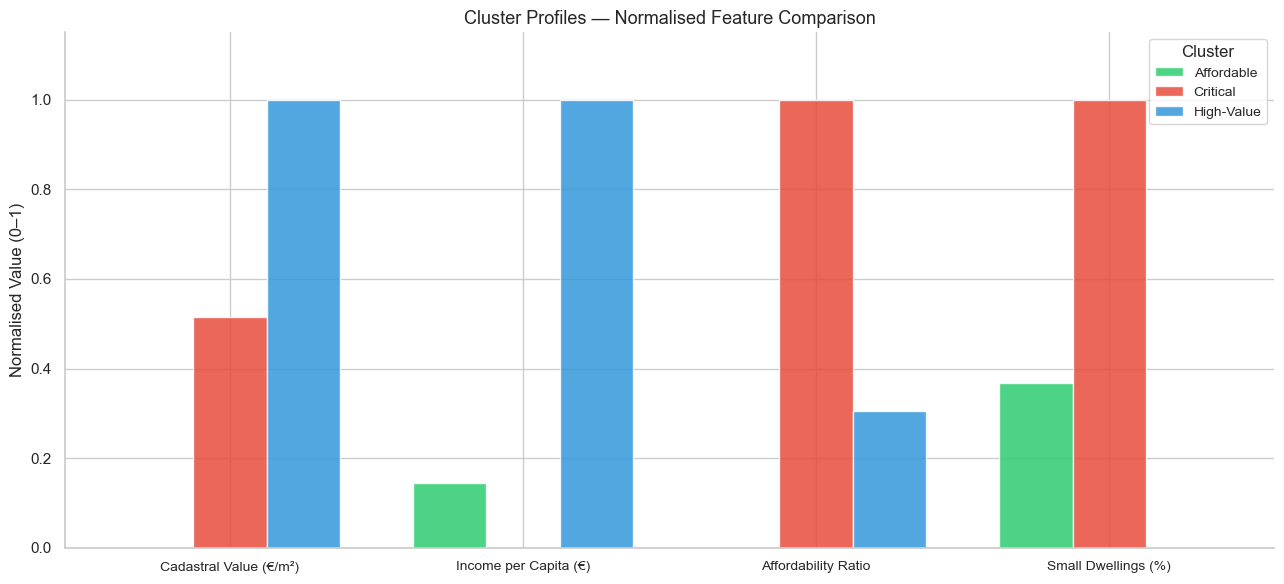

Plot saved.


In [15]:
features_display = {
    'avg_unit_cadastral_value': 'Cadastral Value (€/m²)',
    'avg_income_per_capita'   : 'Income per Capita (€)',
    'avg_affordability_ratio' : 'Affordability Ratio',
    'avg_pct_small_dwellings' : 'Small Dwellings (%)'
}

cluster_means = (
    df_2022.groupby('cluster_label')[list(features_display.keys())]
    .mean()
    .rename(columns=features_display)
)

# Normalise to 0-1 for comparison
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(features_display))
width = 0.25
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, (label, row) in enumerate(cluster_norm.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=label,
                  color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(features_display.values(), fontsize=10)
ax.set_ylabel('Normalised Value (0–1)')
ax.set_title('Cluster Profiles — Normalised Feature Comparison', fontsize=13)
ax.legend(title='Cluster', fontsize=10)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(VIZ / '10_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 7. Interactive Affordability Explorer

Enter your annual household income to see how affordable each Barcelona neighbourhood is for you personally.

The affordability ratio is calculated as: `unit cadastral value / your income`. The colour scale goes from dark green (very affordable) to dark red (very unaffordable).

In [17]:
output = widgets.Output()

income_slider = widgets.IntSlider(
    value=25000,
    min=8000,
    max=60000,
    step=1000,
    description='Annual Income (€):',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='600px')
)

income_label = widgets.Label(value='€25,000')

def format_income(change):
    income_label.value = f'€{change["new"]:,}'

income_slider.observe(format_income, names='value')

# Fixed reference range for colour scale (based on min/max income in slider)
# Fixed reference range for colour scale
RATIO_MIN = 0.010  # dark green — very affordable
RATIO_MAX = 0.060  # dark red — very unaffordable

def update_chart(change):
    with output:
        clear_output(wait=True)
        income = income_slider.value

        df_personal = df_2022.copy()
        df_personal['personal_ratio'] = (
            df_personal['avg_unit_cadastral_value'] / income
        ).round(4)

        df_personal = df_personal.sort_values('personal_ratio', ascending=True)

        # Fixed norm — colours reflect absolute affordability
        norm = plt.Normalize(vmin=RATIO_MIN, vmax=RATIO_MAX)
        cmap = plt.cm.RdYlGn_r
        colors = [cmap(norm(r)) for r in df_personal['personal_ratio']]

        fig, ax = plt.subplots(figsize=(14, 18))
        bars = ax.barh(
            df_personal['neighbourhood_name'] + ' (' + df_personal['district_name'] + ')',
            df_personal['personal_ratio'],
            color=colors
        )

        for bar, val in zip(bars, df_personal['personal_ratio']):
            ax.text(bar.get_width() + 0.0001,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=7)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
        cbar.set_label('Personal Affordability Ratio', fontsize=10)

        ax.set_xlabel('Affordability Ratio (Cadastral Value / Your Income)')
        ax.set_title(
            f'Barcelona Neighbourhood Affordability for Income: €{income:,}/year\n'
            f'Dark green = very affordable · Dark red = very unaffordable',
            fontsize=12
        )
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
        plt.tight_layout()
        plt.show()

income_slider.observe(update_chart, names='value')

ui = widgets.VBox([
    widgets.HBox([income_slider, income_label]),
    output
])
display(ui)
update_chart(None)

In [18]:
output_path = PROCESSED / "clustered_neighbourhoods_2022.csv"
df_2022.to_csv(output_path, index=False)
print("Clustered dataset saved to data/processed/")
print(f"  - clustered_neighbourhoods_2022.csv ({len(df_2022)} neighbourhoods)")

Clustered dataset saved to data/processed/
  - clustered_neighbourhoods_2022.csv (73 neighbourhoods)


## 8. Summary

### Methodology
- **Features:** unit cadastral value, income per capita, affordability ratio, share of small dwellings (≤60m²)
- **Preprocessing:** StandardScaler normalisation
- **Algorithm:** K-Means (k=3, random_state=42)
- **Cluster selection:** Silhouette Score maximised at k=3 (0.39); Elbow Method confirms
- **Dimensionality reduction:** PCA for visualisation (2 components explain 90.8% of variance)

### Cluster Profiles

| Cluster | Label | Neighbourhoods | Cadastral Value | Income | Affordability Ratio | Small Dwellings |
|---|---|---|---|---|---|---|
| 0 | Affordable | 44 | €688/m² | €18,941 | 0.04 | 34% |
| 1 | Critical | 6 | €955/m² | €17,240 | 0.06 | 56% |
| 2 | High-Value | 23 | €1,206/m² | €28,921 | 0.04 | 21% |

### Key findings

**The Critical cluster is geographically concentrated in Ciutat Vella.**
4 of the 6 critical neighbourhoods (la Barceloneta, el Raval, el Gòtic, Sant Pere/Santa Caterina/la Ribera) are in the same district. El Poble Sec and Can Peguera complete the group.

**High cadastral value alone does not define affordability pressure.**
The High-Value cluster has the highest cadastral values (€1,206/m²) but also the highest income (€28,921), resulting in a low affordability ratio (0.04) — similar to the Affordable cluster. The critical factor is the income/value imbalance, not the absolute price.

**The Affordable cluster is the largest (44 neighbourhoods) but the most heterogeneous.**
It spans a wide range of incomes and cadastral values, held together by a low affordability ratio and moderate small dwelling share.

**PCA confirms cluster separation.**
Two principal components explain 90.8% of total variance, and the three clusters are clearly separated in PCA space — validating the quality of the clustering solution.

### Interactive Explorer
The affordability explorer (section 7) allows any user to input their annual income and instantly visualise which neighbourhoods are affordable for their personal situation, with a colour scale ranging from dark green (very affordable) to dark red (very unaffordable).

In [20]:
print("Notebook 04 complete. Project analysis finished.")
print("\nOutputs saved to data/processed/")
print("  - clustered_neighbourhoods_2022.csv")
print("\nVisualisations saved to visualizations/")
print("  - 08_elbow_silhouette.png")
print("  - 09_cluster_pca.png")
print("  - 10_cluster_profiles.png")

Notebook 04 complete. Project analysis finished.

Outputs saved to data/processed/
  - clustered_neighbourhoods_2022.csv

Visualisations saved to visualizations/
  - 08_elbow_silhouette.png
  - 09_cluster_pca.png
  - 10_cluster_profiles.png
